# Identifiability of the interior tide from wet/dry imagery

Published intertidal-DEM methods take one water level per scene from an
ocean tide model evaluated at the estuary mouth. Inside an estuary the
tide arrives late and deformed, so part of that level is wrong.

Our first attempt to fix this did not survive its own diagnostics: a
prototype that inverted a free water level per scene alongside the
elevations improved the correlation and then collapsed under scrutiny —
a free per-scene level is exactly degenerate with a shift of all the
elevations, so the two unknowns were trading information rather than
measuring anything (the scratch scripts are preserved verbatim under
`experiments/prototypes/`). That failure forced the question this
notebook answers before any estimator is trusted: which parameters of
the interior tide are recoverable from binary wet/dry data at all.

**You are here: 01.** Inputs: the wet/dry series of one estuary and the tide at each real overpass. Output: which parameters of the interior tide are estimable at all, and the measured clock profile that notebooks 03–04 consume.

```text
+- the evidence chain ------------------------------------------------+
|  datacube -> water masks -> per-pixel wet/dry series                |
|    01 what is estimable  ->  02 boundary audit  ->  03 operator vs  |
|    gauges  ->  04 elevations vs truth  ->  05 uncertainty and       |
|    hydraulic layers  ->  06 negatives kept  ->  07 coast census     |
+---------------------------------------------------------------------+
```

In [1]:
import json
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# run from the repo root so the results/ paths resolve
here = Path.cwd()
while not (here / "pyintertidal").is_dir():
    if here.parent == here:
        raise FileNotFoundError("repo root not found above " + str(Path.cwd()))
    here = here.parent
os.chdir(here)

def load(path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)

## 1. What a sun-synchronous orbit can sample
The satellite passes at a fixed solar hour, so every tidal constituent
is seen at an aliased period. S2's period divides the solar day exactly,
which freezes it at one phase forever, and K1/P1 alias onto the annual
cycle. The table marks which constituents this archive can estimate.

In [2]:
# alias = apparent period of each constituent when sampled ~once a day
# at a fixed solar hour; "pinned" = held at the boundary prior, not fitted
r = load("results/m2_alias/result.json")

print(f"{r['n_escenas']} real overpasses, mean hour {r['hora_media_utc']:.2f} UTC")

for k, v in sorted(r["tabla"].items(), key=lambda kv: kv[1]["period_h"]):
    al = v["alias_days"]
    tag = "ESTIMABLE" if v["estimable"] else "pinned to boundary prior"
    al_s = "inf" if not np.isfinite(al) else f"{al:6.1f} d"
    print(f"  {k:>3}: alias {al_s} - {tag}")

1380 real overpasses, mean hour 11.26 UTC
   M6: alias    4.9 d - ESTIMABLE
  MS4: alias   14.8 d - ESTIMABLE
   M4: alias    7.4 d - ESTIMABLE
  MN4: alias    5.8 d - ESTIMABLE
   K2: alias  182.6 d - pinned to boundary prior
   S2: alias inf - pinned to boundary prior
   M2: alias   14.8 d - ESTIMABLE
   N2: alias    9.6 d - ESTIMABLE
   K1: alias  365.2 d - pinned to boundary prior
   P1: alias  365.2 d - pinned to boundary prior
   O1: alias   14.2 d - ESTIMABLE
   Q1: alias    9.4 d - ESTIMABLE


### Concepts first: "best terrain", and what the gain α is

**Profiling / best terrain.** A pixel's "terrain" here is its two fitted
parameters: elevation $z_p$ and internal roughness $\sigma_p$. They are
unknown, like the clock — so how do you compare two candidate clocks
fairly? By letting *each candidate present its best case*: to evaluate
$\tau=+40$ min, every pixel re-fits its $(z_p,\sigma_p)$ to whatever best
explains its own record assuming the water ran 40 min late; to evaluate
$\tau=0$, likewise. That is the inner $\max$. The naive alternative —
fit terrain once under $\tau=0$, freeze it, then ask which clock fits —
is rigged: $\tau=0$ wins because the terrain was optimised *for it*, and
terrain error masquerades as clock evidence. With profiling, the only
thing that can decide between clocks is what terrain cannot absorb: a
level shift is absorbed by $z$, but the wrong clock makes the wet/dry
record contradict the tide's *ordering across dates* (scene A carried
more water than B, yet A is dry and B wet) — no fixed elevation repairs a
contradiction that changes sign between scenes.

**The gain α.** Propagating inland, the tide arrives late (phase $\tau$)
*and* can arrive amplified or damped (convergence vs friction):
$h_{int}(t)=\alpha\,h_{mouth}(t-\tau)+datum$. We would love to read
$\alpha$ off the imagery too. The affine identity below is the proof
that it cannot be done: multiply $(\alpha,z,\sigma)$ by any $c$ and every
margin $(\alpha h-z)/\sigma$ is unchanged — a world with $\alpha=1.2$
over terrain $(1.2\,\mathrm{m},0.24\,\mathrm{m})$ produces *exactly* the
same wet/dry record as $\alpha=1$ over $(1.0,0.20)$. They are the same
world observationally; only phase, which reorders dates, survives.

## 2. Recovery gate with planted truth
We plant a known lag profile (0–40 min) and a gain (1.0–1.3) in a
simulation that keeps the real acquisition times, the real cloud masks
and the calibrated noise, and ask the estimators to get them back.
Phase and gain should behave very differently: the Bernoulli likelihood
is invariant under the rescaling (α, z, σ) → (cα, cz, cσ), so the gain
ought to be unrecoverable in principle — the same degeneracy that killed
the prototype above, now stated as a theorem instead of suffered as a
bug.

The machinery, precisely: each pixel's probability of being seen wet in
scene $t$ under a candidate clock $\tau$ is
$P_{pt}=\Phi\big((h(t-\tau)-z_p)/\sigma_p\big)$, and the band's score is
the *profiled* Bernoulli log-likelihood

$$\ell(\tau)=\sum_p \max_{z_p,\sigma_p}\sum_t\big[y_{pt}\log P_{pt}
+(1-y_{pt})\log(1-P_{pt})\big],$$

where the inner max lets every pixel take its best terrain under each
clock, so clocks are compared on equal footing. The invariance is exact:
$(lpha,z,\sigma)\to(clpha,cz,c\sigma)$ leaves every margin
$(h-z)/\sigma$ — and hence every $P_{pt}$ and the whole likelihood —
unchanged, so $\mathrm{NLL}(lpha)$ must come out flat. The right panel checks it in practice; the left panel compares the
recovered lag profiles.

phase RMSE vs planted truth (min): {'m2d': 5.42, 'm2b': 6.7, 'm2c': 13.12, 'm2a': 4.71}


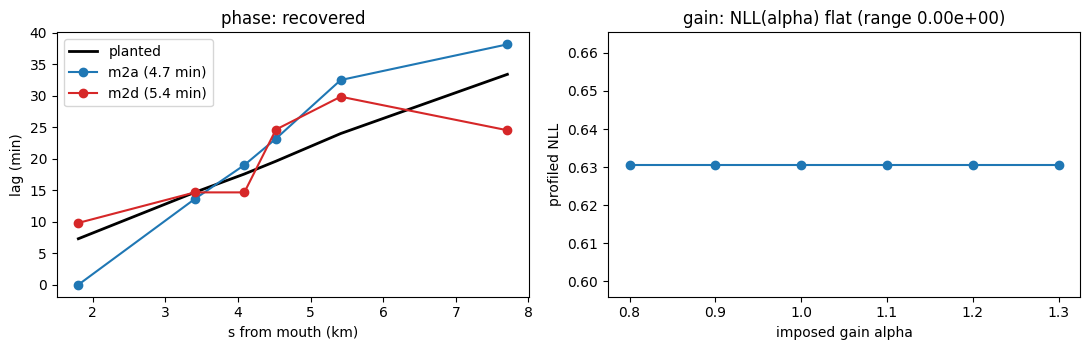

In [3]:
# left panel: recovered lag profiles against the planted one
# right panel: NLL(alpha) — flat means the gain carries no information
r = load("results/m2_gate_sim/result.json")
print("phase RMSE vs planted truth (min):",
      {k: round(v, 2) for k, v in r["rmse_fase_min"].items()})

p = r["perfil_nll_alpha"]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].plot(r["centros_km"], r["tau_true_min"], "k-", lw=2, label="planted")

for k, c in (("m2a", "C0"), ("m2d", "C3")):
    ax[0].plot(r["centros_km"], r["estimadores"][k]["tau"], "o-", color=c,
               label=f"{k} ({r['rmse_fase_min'][k]:.1f} min)")
    
ax[0].set_xlabel("s from mouth (km)"); ax[0].set_ylabel("lag (min)")
ax[0].legend(); ax[0].set_title("phase: recovered")
ax[1].plot(p["malla"], p["nll"], "o-")
ax[1].set_xlabel("imposed gain alpha"); ax[1].set_ylabel("profiled NLL")
ax[1].set_title(f"gain: NLL(alpha) flat (range {p['recorrido']:.2e})")
plt.tight_layout()

### Concepts first: the matched null

An estimator always returns *some* number — clouds, noise and capricious
sampling push the argmax somewhere even when the true lag is zero. So the
question is never "did we measure a lag?" but "**what would this machinery
read if there were nothing to measure?**". We answer it directly: build a
replica world with the effect removed and *everything else kept* — the
same pixels (elevations, contrasts, calibrated noise), the same cloud
masks, the same acquisition times — but a uniform tide. Run the identical
estimator on several replicas; the lags it "measures" there are what pure
sampling noise fabricates, and their spread is the **null band**. A real
measurement is only adopted if it leaves the band. Kitchen-scale version:
weigh *nothing* ten times first; if the empty scale reads −3..+4 g, a
+2 g reading proves nothing and +30 g does. "Matched" is the key word:
the empty-scale test runs on *your* scale in *your* kitchen — comparing
against zero instead would assume the instrument invents nothing, which
is precisely what must be measured.

## 3. The real archive against a matched null
Same estimators on the real Villaviciosa archive. The null band comes
from re-simulating the very same pixels and cloud masks under a uniform
tide, so any lag inside the band can be explained without an interior
tide, and only lags outside it are accepted.

In [4]:
# per band: measured lag, and whether it leaves the uniform-tide null band
r = load("results/m2_real/result.json")
for k, v in r["veredicto"].items():
    print(f"{k:8s} real={np.round(v['real'],1)}")
    print(f"         outside null: {v['fuera_del_nulo']}")

m2a_tau  real=[ 0.   2.6  4.2  7.3  4.1 26.1]
         outside null: [False, False, False, False, False, True]
m2b      real=[-2.1 14.9 14.3 12.  10.5 16.1]
         outside null: [False, True, False, True, False, True]
m2c      real=[-4.2 -0.3 -3.2 -1.1 -3.8 15.4]
         outside null: [True, False, False, False, False, False]
m2d      real=[-5.2  5.   9.9  5.   4.9 24.7]
         outside null: [False, False, True, False, True, True]


The mid-estuary bands stay inside the null; the head band is the only
adopted lag, and the downstream correction carries that and nothing
else.

## 4. Can one parameter replace the free clocks?
With the lag established we tried to compress the free per-band clocks
into a physical law, $\tau(s)=\gamma\,(s-s_0)$ — a single number with a
direct reading: $\gamma=1/c$ is the inverse celerity of the tidal wave,
and for a frictionless shallow-water wave $c=\sqrt{g\bar h}$, so
$\bar h = 1/(g\gamma^2)$ is an effective channel depth. Three
independent estimators of γ were built to keep each other honest: the
profiled likelihood, a rank-correlation sweep per band, and the level
gap between rising and falling scenes. On this archive all three agree
on the sign and none of them leaves its matched null:

In [5]:
# three independent routes to gamma, all scored on the same pixel
# subsample (see experiments/p9*, which share seed and bands)
rows = []
for name, path in (("likelihood", "p9_parametric_lag"),
                   ("rank corr", "p9b_rank_slope"),
                   ("two curves", "p9c_two_curves")):
    r = load(f"results/{path}/result.json")
    rows.append((name, r["gamma_min_per_km"], r["fuera_del_nulo"],
                 len(r["gamma_nulos"])))
print(f"{'estimator':12s} {'gamma (min/km)':>15s} {'outside null':>13s} {'nulls':>6s}")
for n, g, f, k in rows:
    print(f"{n:12s} {g:15.2f} {str(f):>13s} {k:6d}")
nll = load("results/p9_parametric_lag/result.json")["nll"]
print("\nNLL ladder (Villaviciosa):",
      {k: round(v, 4) for k, v in nll.items()})

estimator     gamma (min/km)  outside null  nulls
likelihood              3.25         False      5
rank corr               4.28         False     20
two curves              6.17         False     20

NLL ladder (Villaviciosa): {'uniforme': 0.2979, 'lineal': 0.2947, 'bandas_libres': 0.2939}


So the line was taken to three external sites with survey truth (the
sites of notebook 04) and scored against the free clocks on the thing
that matters — the elevations:

In [6]:
# centred RMSE in metres; the three columns share the same pixels per site
r = load("results/p10_linear_vs_free/result.json")["sitios"]
print(f"{'site':10s} {'gamma_ML':>9s} {'RMSE unif':>10s} {'linear':>8s} {'free':>7s}")
for site, d in r.items():
    print(f"{site:10s} {d['gamma_min_per_km']:9.1f} "
          f"{d['uniforme']['rmse_centrado']:10.3f} "
          f"{d['lineal']['rmse_centrado']:8.3f} "
          f"{d['operador']['rmse_centrado']:7.3f}")

site        gamma_ML  RMSE unif   linear    free
tejo            16.5      0.279    0.267   0.247
vadehavet        8.0      0.274    0.283   0.281
aveiro           6.0      0.589    0.577   0.580


Where the lag profile is smooth the line does the work of several
clocks. Where it is convex (the Tagus) the maximum-likelihood line
steepens to please the estuary head and damages the middle reach:
fitting a wrong shape *better* produced *worse* elevations. The free
per-band clocks therefore stay as the estimator and the line remains a
diagnostic. One procedural lesson from this arc is recorded in the
phase log: an early sweep with a too-narrow γ grid silently regularised
the fit and flattered the line; the honest run required widening the
grid until the optimum was interior, and tuning the cap against the
validation score would have been leakage.